# 📊 Python Phase 2 — Module 3: Data Visualization
## Matplotlib + Seaborn

### Goal
By the end of this notebook you should be able to:
- Understand **why** visualization is used.
- Choose the correct graph for a question.
- Create the most important plots with Matplotlib and Seaborn.
- Interpret distributions, comparisons, relationships, trends, and outliers.
- Practice with a realistic dataset.
- Revise everything through questions at the end.

### Core idea

> **Don't choose a graph because it looks good. Choose it because it answers a specific question.**

### Main libraries

- **Matplotlib** → fundamental plotting + detailed control.
- **Seaborn** → statistical visualization, especially convenient with Pandas DataFrames.

# 1. Visualization — Why, Where and When?

Data visualization converts data into a visual form so that patterns are easier to see.

For example, a table may contain hundreds of values. A graph can make the following visible quickly:

- Trend
- Category comparison
- Distribution
- Relationship/correlation
- Outliers
- Composition

## Typical Data Science workflow

```text
Dataset
   ↓
Pandas → inspect / clean / transform
   ↓
Visualization → understand patterns
   ↓
Statistics / Machine Learning
```

## The 6 questions to remember

| Question | Main graph |
|---|---|
| How does something change? | **Line** |
| Which category is larger? | **Bar** |
| How is a numerical variable distributed? | **Histogram** |
| Are there outliers / how does distribution compare? | **Box plot** |
| Are two numerical variables related? | **Scatter** |
| How does one whole divide into parts? | **Pie** |

Additional useful plots:

| Question | Graph |
|---|---|
| How many observations are in each category? | Count plot |
| How do many numerical variables relate? | Pair plot |
| How strongly are variables correlated? | Heatmap |
| What is the smooth shape of a distribution? | KDE |
| Compare distributions and density across groups | Violin plot |

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 2. Our Practice Dataset

We will create a realistic **student performance dataset**.

It contains:

- `Student_ID`
- `Department`
- `Gender`
- `Study_Hours`
- `Attendance`
- `Assignments`
- `Sleep_Hours`
- `Marks`
- `Placement`
- `Semester`

This dataset is intentionally suitable for many different visualization questions.

> The data is **illustrative practice data**, not real student data.

In [33]:
np.random.seed(42)

n = 120

departments = np.random.choice(
    ["CSE", "ECE", "EE", "ME", "CE"],
    size=n,
    p=[0.30, 0.22, 0.18, 0.16, 0.14]
)

gender = np.random.choice(["Male", "Female"], size=n, p=[0.58, 0.42])

study_hours = np.clip(np.random.normal(5.5, 1.8, n), 1, 10)
attendance = np.clip(np.random.normal(78, 10, n), 50, 100)
assignments = np.random.randint(45, 101, n)
sleep_hours = np.clip(np.random.normal(6.8, 1.0, n), 4, 9)

marks = (
    18
    + 4.8 * study_hours
    + 0.32 * attendance
    + 0.18 * assignments
    + 1.5 * sleep_hours
    + np.random.normal(0, 7, n)
)
marks = np.clip(marks, 35, 100)

placement_probability = (
    1 / (1 + np.exp(-(marks - 72) / 7))
)
placement = np.where(
    np.random.random(n) < placement_probability,
    "Placed",
    "Not Placed"
)

semester = np.random.choice([4, 5, 6, 7, 8], size=n)

df = pd.DataFrame({
    "Student_ID": range(1, n + 1),
    "Department": departments,
    "Gender": gender,
    "Study_Hours": np.round(study_hours, 1),
    "Attendance": np.round(attendance, 1),
    "Assignments": assignments,
    "Sleep_Hours": np.round(sleep_hours, 1),
    "Marks": np.round(marks, 1),
    "Placement": placement,
    "Semester": semester
})

df.head()

,Student_ID,Department,Gender,Study_Hours,Attendance,Assignments,Sleep_Hours,Marks,Placement,Semester
0,1,ECE,Female,5.1,77.8,92,6.2,85.5,Not Placed,7
1,2,CE,Female,6.8,79.2,91,4.6,93.5,Placed,4
2,3,ME,Male,6.4,90.8,67,7.7,100.0,Placed,7
3,4,EE,Male,5.4,72.1,59,5.8,89.0,Placed,8
4,5,CSE,Male,4.0,83.5,81,6.8,86.2,Placed,4


In [35]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (120, 10)

Columns:
['Student_ID', 'Department', 'Gender', 'Study_Hours', 'Attendance', 'Assignments', 'Sleep_Hours', 'Marks', 'Placement', 'Semester']


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   120 non-null    int64  
 1   Department   120 non-null    str    
 2   Gender       120 non-null    str    
 3   Study_Hours  120 non-null    float64
 4   Attendance   120 non-null    float64
 5   Assignments  120 non-null    int32  
 6   Sleep_Hours  120 non-null    float64
 7   Marks        120 non-null    float64
 8   Placement    120 non-null    str    
 9   Semester     120 non-null    int64  
dtypes: float64(4), int32(1), int64(2), str(3)
memory usage: 10.7 KB


In [39]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignments,Sleep_Hours,Marks,Semester
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,60.500000,5.534167,79.210833,72.500000,6.724167,89.830833,5.925000
std,34.785054,1.765472,9.090255,16.440368,1.013190,10.240994,1.490375
min,1.000000,1.000000,56.800000,45.000000,4.100000,51.400000,4.000000
25%,30.750000,4.300000,72.350000,59.000000,6.100000,82.200000,5.000000
50%,60.500000,5.600000,78.750000,71.000000,6.700000,91.750000,6.000000
75%,90.250000,6.700000,84.950000,87.000000,7.425000,100.000000,7.000000
max,120.000000,10.000000,99.900000,100.000000,9.000000,100.000000,8.000000


# 3. Plot 1 — Line Plot

## What?
A line plot connects observations in an order.

## Why?
It makes **change and trend** easy to see.

## When to use?
Use it when the x-axis has a meaningful order, especially:

- Time
- Day
- Month
- Year
- Sequential experiment steps

### Example question
**How do average marks change across semesters?**

> Remember: **LINE → TREND / CHANGE**

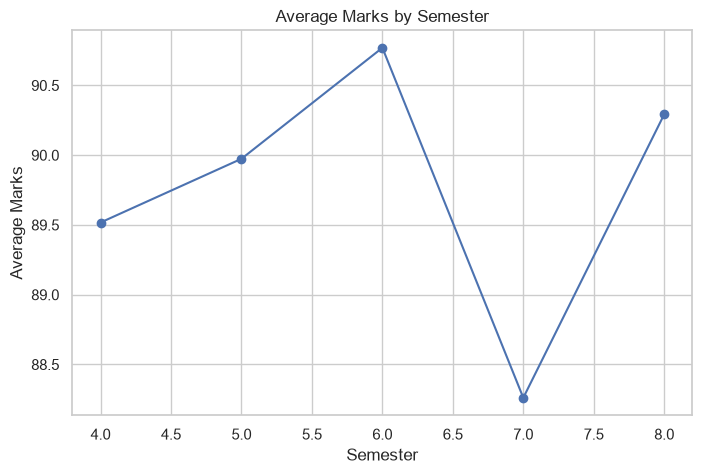

In [42]:
semester_marks = df.groupby("Semester", as_index=False)["Marks"].mean()

plt.figure(figsize=(8, 5))
plt.plot(
    semester_marks["Semester"],
    semester_marks["Marks"],
    marker="o"
)

plt.xlabel("Semester")
plt.ylabel("Average Marks")
plt.title("Average Marks by Semester")
plt.show()

### Interpretation

A line connects the semester averages because semesters have a natural order.

**Do not use a line chart simply because there are numbers on the x-axis.** The order should carry meaning.

# 4. Plot 2 — Bar Chart

## What?
A bar chart compares values across **discrete categories**.

## Why?
The length of each bar makes magnitude easy to compare.

## When?
Use it for:

- Department comparison
- Product comparison
- Country comparison
- Ranking
- Category totals/averages

### Example question
**What is the average mark for each department?**

> Remember: **BAR → CATEGORY COMPARISON**

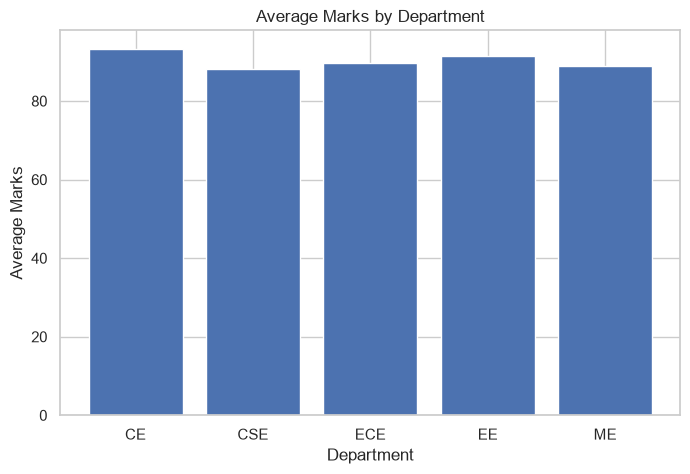

In [43]:
dept_marks = df.groupby("Department", as_index=False)["Marks"].mean()

plt.figure(figsize=(8, 5))
plt.bar(dept_marks["Department"], dept_marks["Marks"])

plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.title("Average Marks by Department")
plt.show()

### Bar vs Line

**Bar:** independent/discrete categories.

**Line:** ordered progression or trend.

For example:
- Average marks by department → **Bar**
- Average marks across semesters → **Line**

# 5. Plot 3 — Histogram

## What?
A histogram divides numerical values into intervals called **bins** and counts observations in each interval.

## Why?
It shows the **distribution** of one numerical variable.

You can investigate:
- Center
- Spread
- Skewness
- Peaks
- Possible unusual values

### Example question
**How are student marks distributed?**

> Remember: **HISTOGRAM → DISTRIBUTION**

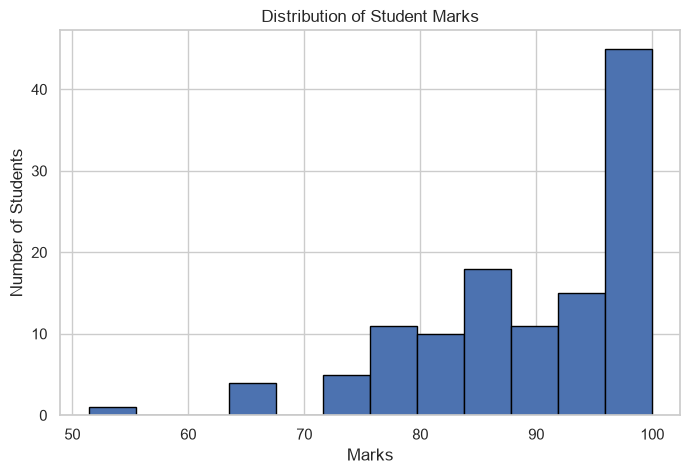

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(df["Marks"], bins=12, edgecolor="black")

plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Marks")
plt.show()

### `bins`

`bins` controls how numerical values are grouped.

- Too few bins → less detail.
- Too many bins → can become noisy.

There is no single correct number for every dataset.

# 6. Plot 4 — Box Plot

## What?
A box plot summarizes a numerical distribution using:

- Q1
- Median
- Q3
- IQR
- Whiskers
- Potential outliers

## Why?
It is excellent for **distribution comparison and outlier detection**.

### Example question
**Do different departments have different mark distributions?**

> Remember: **BOX → DISTRIBUTION + MEDIAN + OUTLIERS**

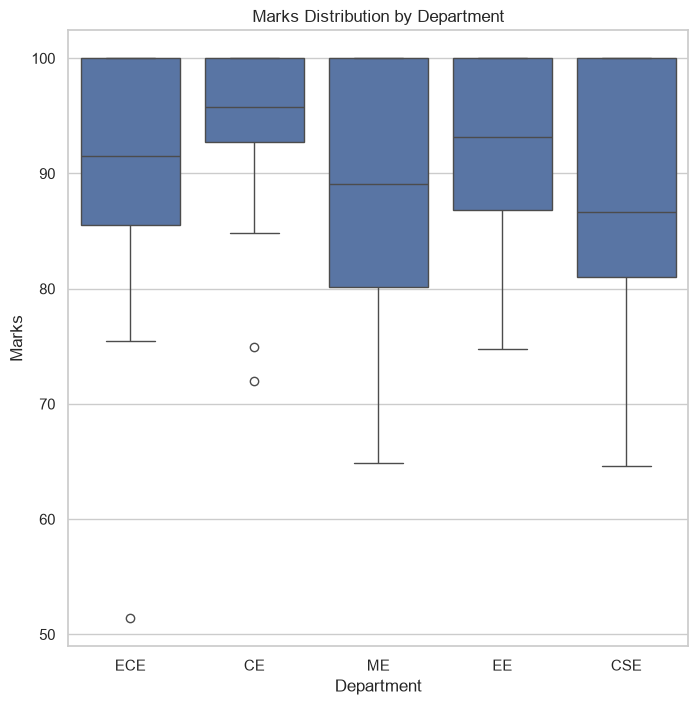

In [48]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=df, x="Department", y="Marks")

plt.xlabel("Department")
plt.ylabel("Marks")
plt.title("Marks Distribution by Department")
plt.show()

### Box plot and outliers

Points beyond the whisker rules may be displayed as individual points.

An outlier is not automatically a mistake. It may represent a genuine observation.

**Never remove an outlier just because a graph shows it. Investigate it first.**

# 7. Plot 5 — Scatter Plot

## What?
A scatter plot displays one point for each observation using two numerical variables.

## Why?
It helps investigate a **relationship/correlation** between two numerical variables.

### Example question
**Is study time related to marks?**

> Remember: **SCATTER → RELATIONSHIP BETWEEN TWO NUMERICAL VARIABLES**

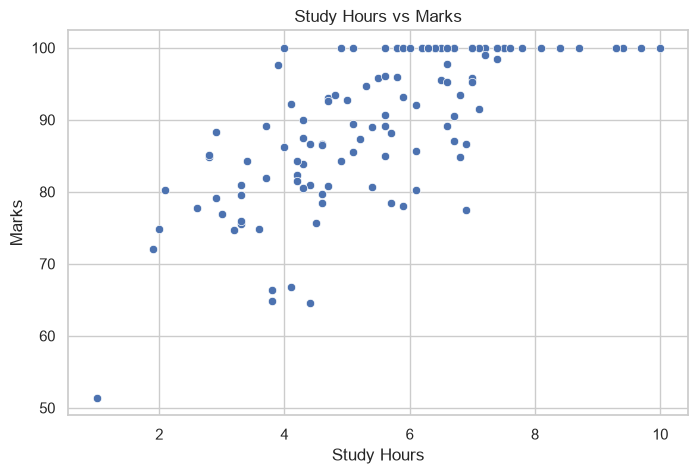

In [49]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Marks"
)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")
plt.show()

## Add a category using `hue`

Seaborn makes this easy.

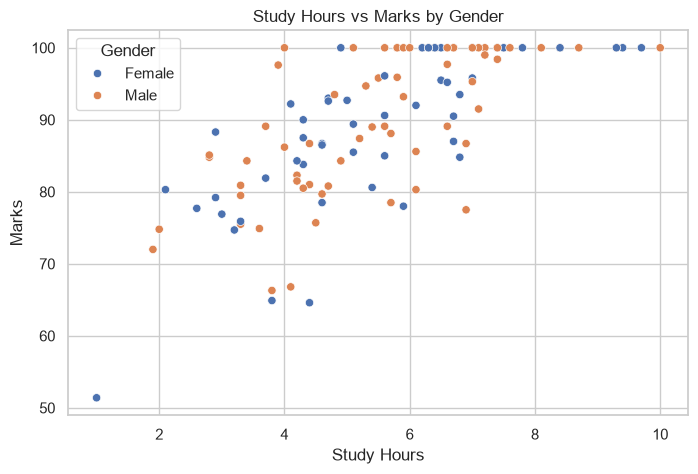

In [50]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Marks",
    hue="Gender"
)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks by Gender")
plt.show()

### Important

A scatter plot can show association, but **correlation does not automatically mean causation**.

Seeing two variables move together does not prove that one causes the other.

# 8. Plot 6 — Count Plot

## What?
A count plot counts how many observations belong to each category.

## Why?
It answers **"How many?"** for categorical data.

### Example questions
- How many students are in each department?
- How many students are placed vs not placed?
- How many students belong to each gender?

> Remember: **COUNT PLOT → CATEGORY FREQUENCY**

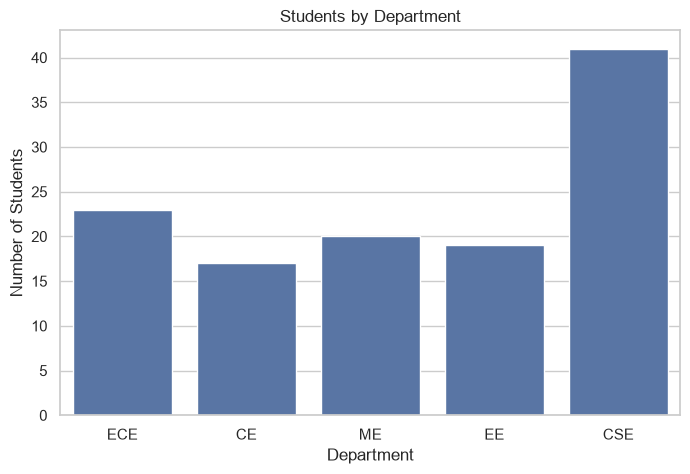

In [51]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Department")

plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.title("Students by Department")
plt.show()

## Count plot vs Bar plot

This distinction is important:

```text
Count plot
→ counts observations

Bar plot
→ displays an aggregate numerical value
   such as mean, sum, etc.
```

# 9. Plot 7 — Pie Chart

## What?
A pie chart shows parts of **one meaningful whole**.

## Why?
It can communicate simple composition/shares.

### Example question
**What proportion of students are placed vs not placed?**

> Remember: **PIE → PART OF A WHOLE**

### Use with caution

Pie charts become difficult to compare when there are many categories or similar-sized slices.

For many categories, a bar chart is usually easier to compare.

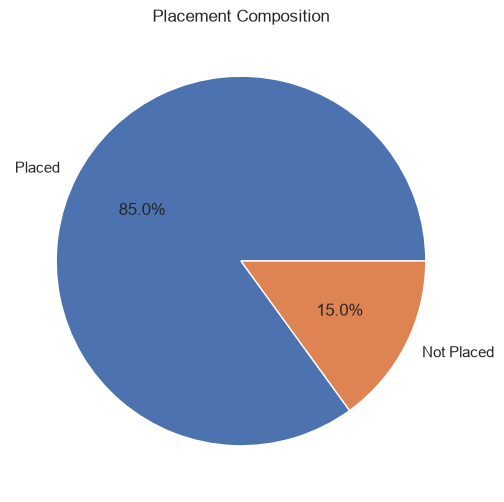

In [52]:
placement_counts = df["Placement"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    placement_counts.values,
    labels=placement_counts.index,
    autopct="%1.1f%%"
)

plt.title("Placement Composition")
plt.show()

# 10. Plot 8 — Heatmap

## What?
A heatmap represents values using visual intensity.

A common Data Science use is a **correlation matrix**.

## Why?
It helps quickly identify which numerical variables have stronger or weaker linear relationships.

### Example question
**Which numerical variables are correlated with each other?**

> Remember: **HEATMAP → MANY-TO-MANY CORRELATION VIEW**

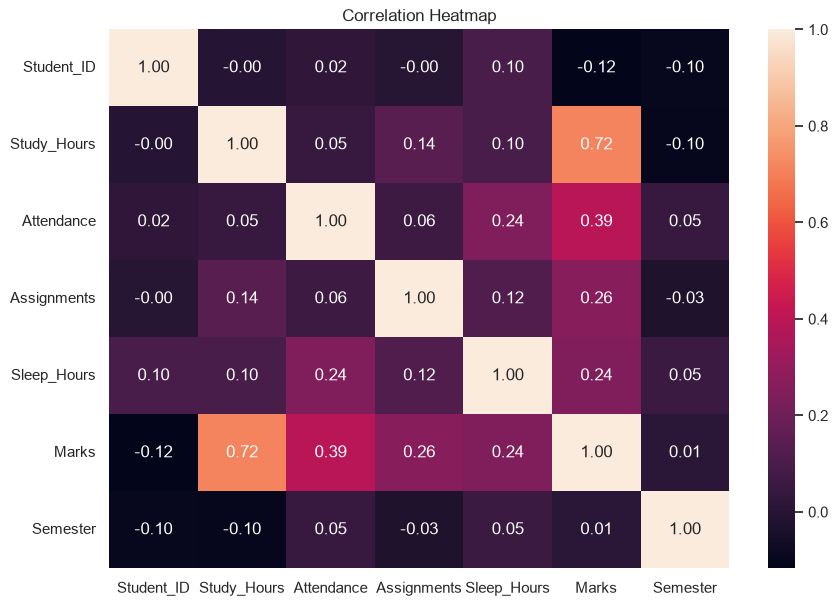

In [53]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Correlation reminder

Correlation generally ranges from **-1 to +1**:

- Near `+1` → strong positive linear association
- Near `0` → weak/no linear association
- Near `-1` → strong negative linear association

Correlation is not proof of causation.

# 11. Plot 9 — Pair Plot

## What?
A pair plot creates a grid showing relationships among multiple numerical variables.

## Why?
It is useful for **initial exploratory data analysis (EDA)**.

### Example question
**How do Study Hours, Attendance, Assignments, Sleep Hours and Marks relate to each other?**

> Remember: **PAIR PLOT → MANY NUMERICAL RELATIONSHIPS AT ONCE**

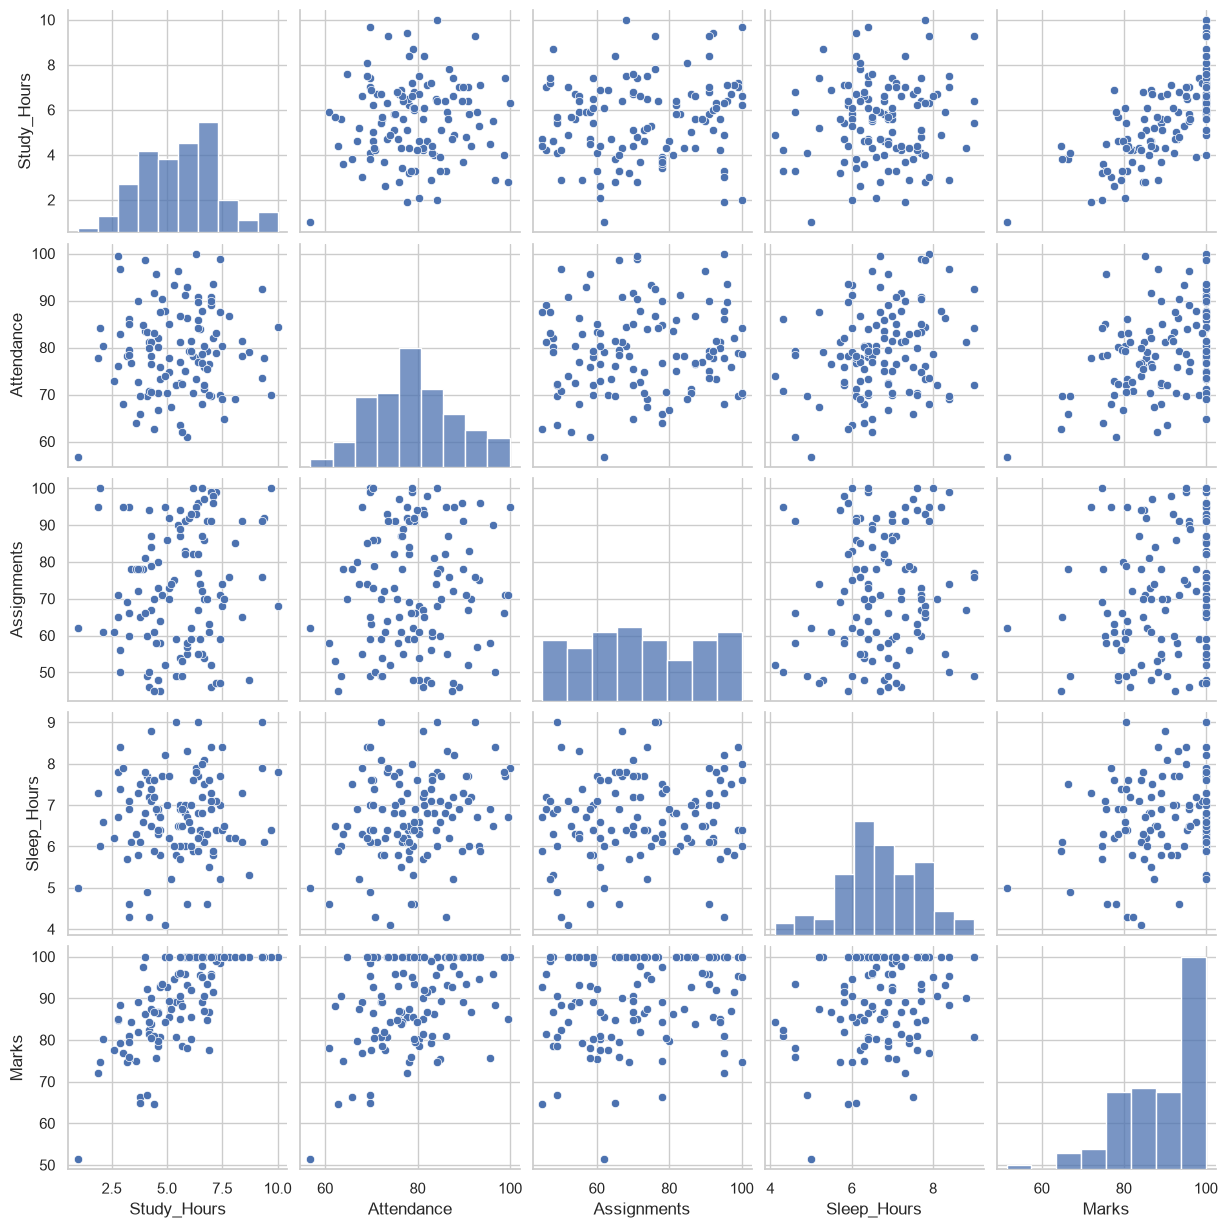

In [54]:
sns.pairplot(
    df[["Study_Hours", "Attendance", "Assignments", "Sleep_Hours", "Marks"]]
)

plt.show()

Pair plots can become crowded with too many variables.

Use them as an exploratory tool, not as the final visualization for every report.

# 12. Plot 10 — Violin Plot

## What?
A violin plot shows the distribution/density of numerical values across categories.

## Why?
It can reveal the **shape of distributions** while comparing groups.

### Example question
**How is the mark distribution shaped across departments?**

> Remember: **VIOLIN → DISTRIBUTION SHAPE + GROUP COMPARISON**

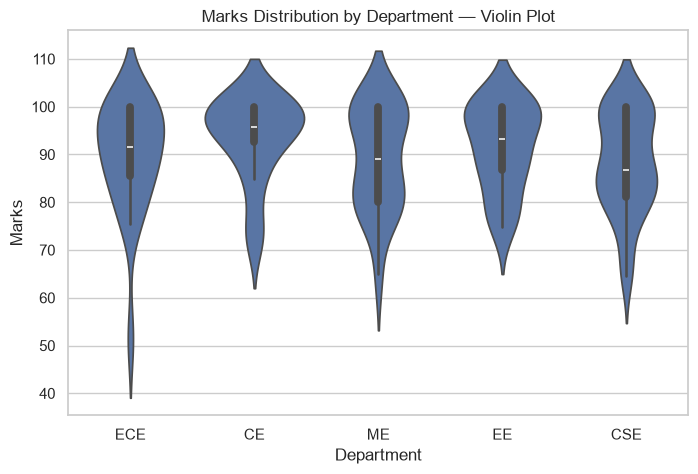

In [55]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Department", y="Marks")

plt.xlabel("Department")
plt.ylabel("Marks")
plt.title("Marks Distribution by Department — Violin Plot")
plt.show()

### Box vs Violin

**Box plot**
- Easier to read
- Great for median, quartiles and outliers

**Violin plot**
- Shows more of the distribution shape
- Can be harder for beginners to interpret

# 13. Plot 11 — KDE Plot

## What?
KDE = **Kernel Density Estimate**.

It provides a smooth estimate of a numerical distribution.

## Why?
Useful when you want to examine the shape of a distribution without histogram bins.

> Remember: **KDE → SMOOTH DISTRIBUTION**

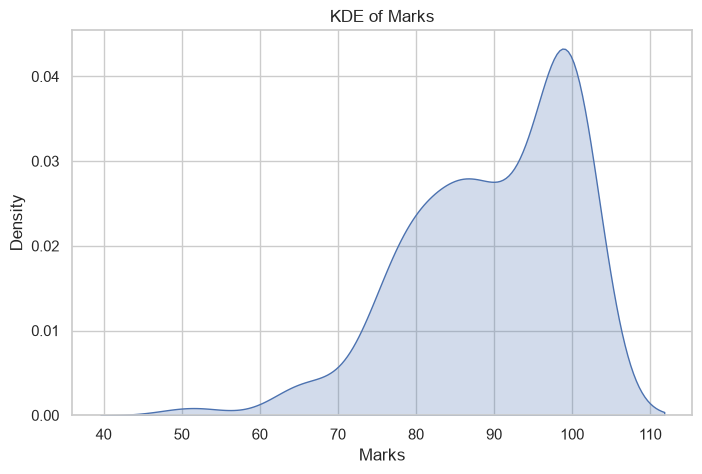

In [56]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="Marks", fill=True)

plt.xlabel("Marks")
plt.ylabel("Density")
plt.title("KDE of Marks")
plt.show()

For beginner-level EDA, a histogram is usually easier to understand. Learn KDE mainly as another way to visualize a distribution.

# 14. Plot 12 — Regression Plot

## What?
A regression plot combines a scatter plot with an estimated regression line.

## Why?
It helps visually examine a possible **linear relationship**.

### Example question
**Does study time show an approximately linear relationship with marks?**

> Remember: **REGPLOT → SCATTER + TREND LINE**

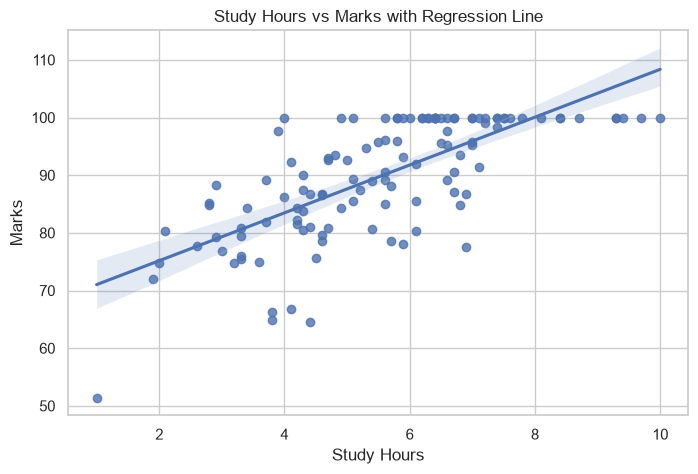

In [57]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="Study_Hours",
    y="Marks"
)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks with Regression Line")
plt.show()

# 15. Subplots — Multiple Views

When you want to show several related visualizations together, use subplots.

```text
Figure
 ├── Axes 1
 ├── Axes 2
 └── ...
```

Example:

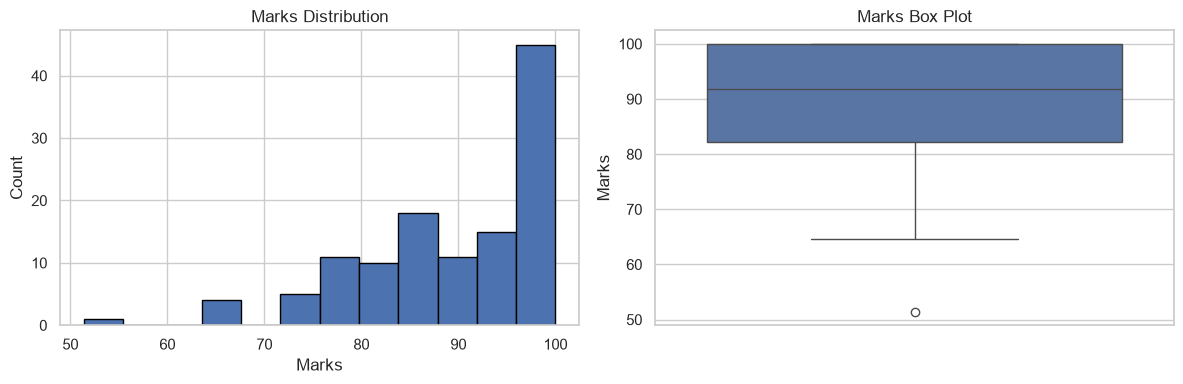

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Marks"], bins=12, edgecolor="black")
axes[0].set_title("Marks Distribution")
axes[0].set_xlabel("Marks")
axes[0].set_ylabel("Count")

sns.boxplot(data=df, y="Marks", ax=axes[1])
axes[1].set_title("Marks Box Plot")

plt.tight_layout()
plt.show()

# 16. Essential Matplotlib Syntax

```python
import matplotlib.pyplot as plt

plt.plot(x, y)
plt.bar(x, y)
plt.barh(x, y)
plt.scatter(x, y)
plt.hist(x)
plt.pie(values, labels=labels)
plt.boxplot(x)

plt.xlabel("X label")
plt.ylabel("Y label")
plt.title("Title")
plt.legend()
plt.grid()
plt.figure(figsize=(8, 5))
plt.show()
plt.savefig("plot.png")
```

### Modern Matplotlib style

For more complex figures:

```python
fig, ax = plt.subplots()

ax.plot(x, y)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Title")

plt.show()
```

Think:

```text
Figure → complete canvas
Axes   → actual plotting area
```

# 17. Essential Seaborn Syntax

```python
import seaborn as sns

sns.lineplot()
sns.barplot()
sns.scatterplot()
sns.countplot()
sns.histplot()
sns.boxplot()
sns.violinplot()
sns.kdeplot()
sns.heatmap()
sns.pairplot()
sns.regplot()
```

Most Seaborn functions work naturally with Pandas:

```python
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Marks"
)
```

This is one reason Seaborn is very convenient for DataFrame-based EDA.

# 18. Plot Selection — MASTER TABLE ⭐

| Your question | Plot | Data type |
|---|---|---|
| How does a value change over time/order? | **Line** | Ordered x + numeric y |
| Which categories have larger values? | **Bar** | Categorical + numeric |
| How many observations are in each category? | **Count** | Categorical |
| What does one numerical variable look like? | **Histogram** | Numeric |
| Are there unusual values / outliers? | **Box** | Numeric |
| Compare distributions between groups | **Box / Violin** | Category + numeric |
| Are two numerical variables related? | **Scatter** | Numeric + numeric |
| Show approximate linear trend | **Regression plot** | Numeric + numeric |
| What fraction makes up one whole? | **Pie** | Categories + shares |
| How are many numeric variables related? | **Pair plot** | Multiple numeric |
| Which numeric variables correlate? | **Heatmap** | Correlation matrix |
| Show smooth distribution | **KDE** | Numeric |

## The memory formula

```text
LINE      → TREND
BAR       → COMPARE
COUNT     → HOW MANY
HIST      → DISTRIBUTION
BOX       → OUTLIERS
SCATTER   → RELATIONSHIP
PIE       → PART OF WHOLE
HEATMAP   → CORRELATION
PAIRPLOT  → MANY RELATIONSHIPS
VIOLIN    → DISTRIBUTION SHAPE
KDE       → SMOOTH DISTRIBUTION
```

# 19. Common Mistakes

### Mistake 1 — Using a line chart for unrelated categories

If departments are just categories, use a bar chart.

### Mistake 2 — Using pie charts everywhere

Pie charts are mainly for simple part-to-whole composition.

### Mistake 3 — Confusing histogram and bar chart

```text
Histogram → numerical continuous/distribution data
Bar      → categorical comparison
```

### Mistake 4 — Thinking correlation means causation

A scatter plot or correlation matrix shows association, not proof of cause.

### Mistake 5 — Automatically deleting outliers

Investigate an outlier before removing it.

### Mistake 6 — Too many things on one graph

A visualization should communicate a clear message.

### Mistake 7 — Forgetting labels

A graph should normally make clear:
- What is being measured?
- What are the units?
- What do the axes represent?

# 20. Practical EDA Workflow

When you receive a new dataset, follow this sequence.

### Step 1 — Inspect

```python
df.head()
df.shape
df.info()
df.describe()
```

### Step 2 — Understand columns

Separate:

```text
Categorical
Numeric
Date/time
```

### Step 3 — Ask a question

Don't start by randomly creating graphs.

Example:

> "Is attendance related to marks?"

### Step 4 — Choose the graph

```text
Attendance → numeric
Marks      → numeric

Therefore → Scatter
```

### Step 5 — Interpret

Don't just create the graph. Ask:

- What pattern do I see?
- Is it strong or weak?
- Are there outliers?
- Are groups different?
- Could there be another explanation?

### Step 6 — Use statistics/ML if needed

Visualization helps you **explore**; it doesn't replace statistical analysis.

# 21. Revision Questions 🧠

## A. Identify the graph

For each situation, write the most suitable graph.

### Q1
You have monthly sales from January to December. You want to see the trend.

**Answer:** __________________

### Q2
You want to compare average salary across 5 departments.

**Answer:** __________________

### Q3
You want to see how exam marks are distributed among 500 students.

**Answer:** __________________

### Q4
You want to detect unusually high/low salaries.

**Answer:** __________________

### Q5
You want to examine the relationship between study hours and marks.

**Answer:** __________________

### Q6
You want to count how many students belong to each department.

**Answer:** __________________

### Q7
You want to show the percentage contribution of 4 expense categories to total expenses.

**Answer:** __________________

### Q8
You have 6 numerical features and want a quick visual exploration of their pairwise relationships.

**Answer:** __________________

### Q9
You want to see correlations among 10 numerical features.

**Answer:** __________________

### Q10
You want to compare the distribution shape of marks across departments.

**Answer:** __________________

# 22. Revision Questions — Code Practice 🔥

Use the `df` dataset above.

### Q11
Represent the number of students in each `Department`.

**Expected plot:** Count plot / bar chart.

---

### Q12
Represent the distribution of `Attendance`.

**Expected plot:** Histogram.

---

### Q13
Represent `Study_Hours` vs `Marks`.

**Expected plot:** Scatter plot.

---

### Q14
Compare the distribution of `Marks` among departments.

**Expected plot:** Box plot.

---

### Q15
Show average `Marks` by `Department`.

**Expected plot:** Bar plot.

---

### Q16
Show the percentage of `Placed` vs `Not Placed`.

**Expected plot:** Pie chart.

---

### Q17
Create a correlation heatmap for all numerical columns.

**Expected plot:** Heatmap.

---

### Q18
Create a pair plot using:

```python
Study_Hours
Attendance
Assignments
Sleep_Hours
Marks
```

**Expected plot:** Pair plot.

---

### Q19
Show `Study_Hours` vs `Marks` with a regression line.

**Expected plot:** Regression plot.

---

### Q20 — Challenge ⭐

For `Marks`, create:

1. Histogram
2. Box plot
3. KDE

Then explain what each visualization tells you that the others do not.

# 23. Final Challenge — Choose Without Looking at the Table ⭐⭐⭐

For each question, first decide the graph **before writing code**.

### Challenge 1
A company has yearly revenue from 2018–2025.

→ Graph: __________

### Challenge 2
A company wants to compare revenue among product categories in 2025.

→ Graph: __________

### Challenge 3
A company wants to know whether advertising spend and sales are related.

→ Graph: __________

### Challenge 4
HR wants to compare salary distributions across departments and identify unusual salaries.

→ Graph: __________

### Challenge 5
A data scientist wants to inspect correlations among 15 numerical features.

→ Graph: __________

### Challenge 6
A manager wants to know how many employees belong to each job category.

→ Graph: __________

### Challenge 7
A report needs to show how the total budget is divided among 4 major categories.

→ Graph: __________

### Challenge 8
You receive an unfamiliar dataset and want a quick view of relationships among 5 numerical variables.

→ Graph: __________

# 24. Tips to Learn Visualization 🚀

## Tip 1 — Learn by question, not by function

Don't memorize:

```python
sns.scatterplot()
```

as an isolated command.

Memorize:

> **Two numerical variables + relationship → Scatter plot**

Then the syntax becomes easy to recall.

---

## Tip 2 — Master 6 plots first

If you remember only these initially:

```text
1. Line
2. Bar
3. Histogram
4. Box
5. Scatter
6. Heatmap
```

you can already solve a large portion of practical EDA tasks.

---

## Tip 3 — Always ask "What are my variables?"

Before plotting:

```text
X → categorical or numerical?
Y → categorical or numerical?
Time/order?
One variable or two?
Distribution?
```

---

## Tip 4 — Don't confuse these

```text
Histogram → Distribution
Bar       → Category comparison
Count     → Category frequency

Scatter   → Numeric vs Numeric
Box       → Distribution + outliers
```

---

## Tip 5 — Visualization is for understanding

The goal isn't:

> "I created 10 graphs."

The goal is:

> "I discovered something useful about the data."

---

## Tip 6 — Practice the same dataset repeatedly

Use one dataset and answer different questions.

For this notebook:

```text
Department
Study_Hours
Attendance
Assignments
Sleep_Hours
Marks
Placement
```

Try to find:

- Best/worst category comparisons
- Distributions
- Relationships
- Outliers
- Correlations
- Composition

---

## Tip 7 — Connect the libraries

Your Phase 2 workflow should become:

```text
NumPy
  ↓
Numerical operations

Pandas
  ↓
Data manipulation

Matplotlib
  ↓
Fundamental visualization

Seaborn
  ↓
Statistical visualization

Scikit-learn
  ↓
Machine Learning
```

---

# 🏆 Final Memory Map

```text
                DATA VISUALIZATION
                       │
        ┌──────────────┼──────────────┐
        ↓              ↓              ↓
      TREND         COMPARE       RELATIONSHIP
        │              │              │
      LINE        BAR / COUNT      SCATTER
                       │
                       ↓
                  DISTRIBUTION
                       │
              ┌────────┼────────┐
              ↓        ↓        ↓
           HISTOGRAM  BOX     VIOLIN
                       │
                       ↓
                    OUTLIERS

        MANY VARIABLES
              │
       ┌──────┴──────┐
       ↓             ↓
   PAIR PLOT      HEATMAP
                    │
                    ↓
                CORRELATION

             PART OF WHOLE
                   ↓
                  PIE
```

## One-line revision

> **Line = trend | Bar = compare | Count = frequency | Histogram = distribution | Box = outliers | Scatter = relationship | Pie = part of whole | Heatmap = correlation | Pair plot = many relationships | Violin = distribution shape | KDE = smooth distribution**

# 🏆 COMPLETE ANSWER KEY + APPLICABILITY GUIDE

This section contains the answers to **all revision and challenge questions** from this notebook.

> **Important:** Try each question yourself first, then check the answer.

## Part A — Identify the Graph: Answers

| Q | Situation | Answer | Why / When applicable |
|---|---|---|---|
| 1 | Monthly sales Jan–Dec, see trend | **Line Plot** | Ordered/time-based data and trends |
| 2 | Compare average salary across departments | **Bar Plot** | Compare numerical values across categories |
| 3 | Distribution of marks of 500 students | **Histogram** | Distribution of one numerical variable |
| 4 | Detect unusually high/low salaries | **Box Plot** | Distribution, quartiles and potential outliers |
| 5 | Study hours vs marks | **Scatter Plot** | Relationship between two numerical variables |
| 6 | Count students in each department | **Count Plot** | Frequency of categorical observations |
| 7 | Percentage contribution of expenses | **Pie Chart** | Parts of one meaningful whole |
| 8 | 6 numerical features and pairwise relationships | **Pair Plot** | Explore many numerical relationships |
| 9 | Correlations among 10 numerical features | **Heatmap** | Visualize a correlation matrix |
| 10 | Mark distribution shape across departments | **Violin Plot** | Compare distribution shapes across groups |

## Part B — Coding Practice: Answers

The following examples use the `df` dataset created earlier in this notebook.

### Q11 — Number of students in each department

**Answer: Count Plot**

Use it when the question asks **"How many observations are in each category?"**

In [ ]:
sns.countplot(data=df, x="Department")
plt.title("Number of Students by Department")
plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.show()

**Applicable to:** students by department, employees by role, customers by type, orders by category.

### Count Plot vs Bar Plot

- `countplot()` → counts observations.
- `barplot()` → displays an aggregate numerical value such as mean.

### Q12 — Distribution of Attendance

**Answer: Histogram**

Use it when you want the distribution of one numerical variable.

In [ ]:
plt.hist(df["Attendance"], bins=10, edgecolor="black")
plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Frequency")
plt.show()

**Applicable to:** marks, age, salary, height, weight, temperature and other numerical variables.

### Q13 — Study Hours vs Marks

**Answer: Scatter Plot**

Both variables are numerical and we want to investigate their relationship.

In [ ]:
sns.scatterplot(data=df, x="Study_Hours", y="Marks")
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()

**Applicable to:** height vs weight, advertising spend vs sales, age vs salary, study hours vs marks.

> A scatter plot can show association, but association alone does not prove causation.

### Q14 — Marks distribution among departments

**Answer: Box Plot**

We want distribution + group comparison + potential outliers.

In [ ]:
sns.boxplot(data=df, x="Department", y="Marks")
plt.title("Marks Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Marks")
plt.show()

**Applicable to:** salary across departments, marks across branches, prices across categories.

An outlier is not automatically an error. Investigate it before removing it.

### Q15 — Average Marks by Department

**Answer: Bar Plot**

Seaborn's bar plot aggregates the numerical variable by category.

In [ ]:
sns.barplot(data=df, x="Department", y="Marks")
plt.title("Average Marks by Department")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()

**Applicable to:** average salary by department, average sales by region, average marks by class.

> `barplot` answers a numerical aggregate question; `countplot` answers a frequency question.

### Q16 — Percentage of Placed vs Not Placed

**Answer: Pie Chart**

Use it for a simple composition where categories form one meaningful whole.

In [ ]:
placement = df["Placement"].value_counts()

plt.pie(
    placement.values,
    labels=placement.index,
    autopct="%1.1f%%"
)
plt.title("Placement Status")
plt.show()

**Applicable to:** simple budget allocation, market share, placement composition.

Avoid pie charts when there are many categories or when exact comparisons are important.

### Q17 — Correlation Heatmap

**Answer: Heatmap**

Create a correlation matrix and visualize it.

In [ ]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Applicable to:** EDA, feature analysis and quickly inspecting relationships among many numerical variables.

Correlation is not proof of causation.

### Q18 — Pair Plot

**Answer: Pair Plot**

Useful when you have a small/moderate number of numerical variables and want a quick overview of their pairwise relationships.

In [ ]:
sns.pairplot(
    df[
        [
            "Study_Hours",
            "Attendance",
            "Assignments",
            "Sleep_Hours",
            "Marks"
        ]
    ]
)
plt.show()

**Applicable to:** initial exploratory data analysis.

Pair plots can become crowded if you include too many variables.

### Q19 — Study Hours vs Marks with Regression Line

**Answer: Regression Plot**

In [ ]:
sns.regplot(data=df, x="Study_Hours", y="Marks")
plt.title("Study Hours vs Marks with Regression Line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()

**Applicable to:** visually examining an approximately linear relationship between two numerical variables.

### Q20 — Marks: Histogram + Box Plot + KDE

#### Histogram
Shows frequency/distribution using bins.

#### Box Plot
Shows median, quartiles, spread and potential outliers.

#### KDE
Shows a smooth estimated distribution.

```text
Histogram → frequency + distribution
Box       → median + quartiles + outliers
KDE       → smooth distribution shape
```

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["Marks"], bins=12, edgecolor="black")
axes[0].set_title("Histogram")
axes[0].set_xlabel("Marks")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df, y="Marks", ax=axes[1])
axes[1].set_title("Box Plot")
axes[1].set_ylabel("Marks")

sns.kdeplot(data=df, x="Marks", fill=True, ax=axes[2])
axes[2].set_title("KDE")
axes[2].set_xlabel("Marks")

plt.tight_layout()
plt.show()

# Part C — Final Challenge: Answers

### Challenge 1
Company has yearly revenue from 2018–2025.

**Answer: Line Plot**

**Applicable:** time/order → trend or change.

### Challenge 2
Compare revenue among product categories in 2025.

**Answer: Bar Plot**

**Applicable:** category → numerical comparison.

### Challenge 3
Advertising spend and sales relationship.

**Answer: Scatter Plot**

**Applicable:** numerical variable ↔ numerical variable.

### Challenge 4
Compare salary distributions across departments and identify unusual salaries.

**Answer: Box Plot**

**Applicable:** numerical distribution + category comparison + potential outliers.

### Challenge 5
Correlations among 15 numerical features.

**Answer: Heatmap**

**Applicable:** correlation matrix / many numerical variables.

### Challenge 6
Number of employees in each job category.

**Answer: Count Plot**

**Applicable:** categorical frequency / "How many?"

### Challenge 7
Total budget divided among 4 categories.

**Answer: Pie Chart**

**Applicable:** simple parts of one whole.

### Challenge 8
Unfamiliar dataset + 5 numerical variables + quick relationship exploration.

**Answer: Pair Plot**

**Applicable:** quick exploratory view of many numerical relationships.

# ⭐ MASTER APPLICABILITY TABLE

| Graph | Use when you want to know... | Typical variables |
|---|---|---|
| **Line** | How does it change/trend? | Ordered/time + numeric |
| **Bar** | Which category is bigger? | Category + numeric |
| **Count** | How many are in each category? | Category |
| **Histogram** | How is one numeric variable distributed? | Numeric |
| **Box** | What is the distribution? Are there potential outliers? | Numeric, optionally grouped by category |
| **Scatter** | Are two numeric variables related? | Numeric + numeric |
| **Pie** | How is one whole divided? | Categories + shares |
| **Heatmap** | How do many variables correlate? | Correlation matrix |
| **Pair Plot** | How do many numeric variables relate? | Multiple numeric |
| **Violin** | What is the distribution shape across groups? | Category + numeric |
| **KDE** | What is the smooth distribution shape? | Numeric |
| **Regression Plot** | Is there an approximate linear trend? | Numeric + numeric |

## Fast memory rule

```text
LINE      → TREND
BAR       → COMPARE
COUNT     → HOW MANY
HISTOGRAM → DISTRIBUTION
BOX       → OUTLIERS
SCATTER   → RELATIONSHIP
PIE       → PART OF WHOLE
HEATMAP   → CORRELATION
PAIRPLOT  → MANY RELATIONSHIPS
VIOLIN    → DISTRIBUTION SHAPE
KDE       → SMOOTH DISTRIBUTION
REGPLOT   → RELATIONSHIP + TREND LINE
```

# 🧠 HOW TO CHOOSE A GRAPH IN AN EXAM / PROJECT

Before writing code, ask these questions:

### Step 1 — What type of data do I have?

```text
Categorical?
Numerical?
Date/time?
```

### Step 2 — What am I trying to discover?

```text
Trend?
Comparison?
Frequency?
Distribution?
Outlier?
Relationship?
Correlation?
Composition?
```

### Step 3 — Select the graph

```text
Trend                 → Line
Category comparison   → Bar
Category frequency    → Count
Distribution          → Histogram
Outliers              → Box
2 numeric relationship→ Scatter
Correlation matrix    → Heatmap
Parts of whole        → Pie
Many relationships    → Pair Plot
Distribution by group → Box / Violin
Smooth distribution   → KDE
Relationship + line   → Regression Plot
```

### Step 4 — Interpret the graph

Always ask:

- What pattern do I see?
- What is the center?
- How spread out is it?
- Are there unusual values?
- Are groups different?
- Is the relationship positive, negative or weak?
- Could another factor explain the pattern?

# 🚀 LEARNING TIPS

### Tip 1 — Learn the question, not the function

Instead of memorizing:

```python
sns.scatterplot()
```

remember:

> **Two numerical variables + relationship → Scatter Plot**

---

### Tip 2 — Master these six first

```text
Line
Bar
Histogram
Box
Scatter
Heatmap
```

These cover a large amount of practical EDA.

---

### Tip 3 — Practice with one dataset

Use the same dataset repeatedly and ask different questions.

This teaches **graph selection**, not just syntax.

---

### Tip 4 — Don't randomly create graphs

Start with:

> "What question am I trying to answer?"

Then select the graph.

---

### Tip 5 — Don't automatically remove outliers

An outlier can be:
- A real observation
- A measurement issue
- A data-entry mistake
- A rare but meaningful case

Investigate first.

---

### Tip 6 — Remember the difference

```text
Histogram → numerical distribution
Bar       → category comparison
Count     → category frequency
Scatter   → numeric relationship
Box       → distribution + outliers
```

---

### Tip 7 — Visualization is exploratory

A graph helps you discover patterns. It does not automatically prove a statistical or causal conclusion.

# 🏁 COMPLETE MODULE CHECKLIST

Before moving to the next module, you should be able to explain:

- [ ] What Data Visualization is
- [ ] Matplotlib vs Seaborn
- [ ] Figure vs Axes
- [ ] Line plot
- [ ] Bar plot
- [ ] Count plot
- [ ] Histogram
- [ ] Box plot
- [ ] Scatter plot
- [ ] Pie chart
- [ ] Heatmap
- [ ] Pair plot
- [ ] Violin plot
- [ ] KDE
- [ ] Regression plot
- [ ] Subplots
- [ ] How to select a graph from a question
- [ ] Difference between histogram and bar
- [ ] Difference between countplot and barplot
- [ ] Why scatter does not prove causation
- [ ] Why outliers should be investigated before removal

## Final test

If you can see a dataset and immediately think:

```text
"Trend?"          → Line
"Compare?"        → Bar
"How many?"       → Count
"Distribution?"   → Histogram
"Outliers?"       → Box
"Relationship?"   → Scatter
"Correlation?"    → Heatmap
"Whole/parts?"    → Pie
"Many variables?" → Pair Plot
```

then your visualization foundation is strong.